# Entrenamieto y Análisis de Modelo Híbrido: PyCaret + Scikit-learn

Este notebook implementa un pipeline de entrenamiento híbrido y realiza un análisis gráfico exhaustivo del rendimiento del modelo.

## Estrategia
1. **PyCaret (Muestra 20%)**: Selección rápida y diagnóstico visual del mejor modelo.
2. **Scikit-learn (Full Data)**: Entrenamiento final y validación de errores.

## 📊 Análisis Gráfico Incluido
- **Residuals Plot**: Distribución de los errores (¿Sobrepredice o subpredice?).
- **Prediction Error**: Comparación visual Real vs Predicho.
- **Feature Importance**: Qué variables definen la satisfacción gastronómica.

In [47]:
import pandas as pd
import numpy as np
import os
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.regression import setup, compare_models, evaluate_model, plot_model, pull
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")

# Config
DATA_DIR = '../data'
MODELS_DIR = '../models'
SEED = 42

## 1. Carga de Datos

In [48]:
def load_data():
    interacciones = pd.read_csv(os.path.join(DATA_DIR, 'interacciones_web_enriquecido_v2.csv'))
    turistas = pd.read_csv(os.path.join(DATA_DIR, 'turistas_enriquecido.csv'))
    restaurantes = pd.read_csv(os.path.join(DATA_DIR, 'restaurantes_web_enriquecido_v2.csv'))
    return interacciones, turistas, restaurantes

df_int, df_tur, df_rest = load_data()
print(f"Interacciones: {df_int.shape}, Turistas: {df_tur.shape}, Restaurantes: {df_rest.shape}")

Interacciones: (14553, 19), Turistas: (3000, 21), Restaurantes: (210, 30)


## 2. Feature Engineering & Preprocesamiento

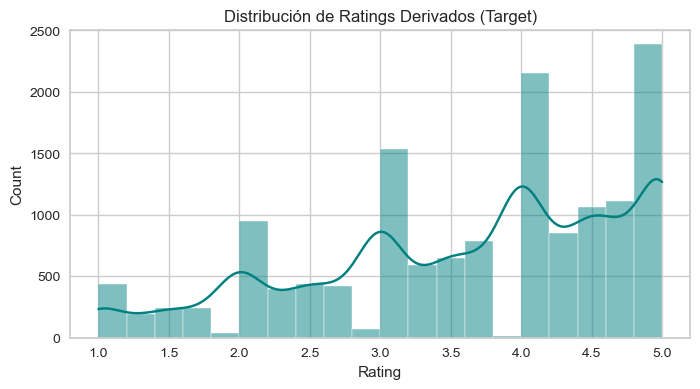

In [49]:
def preprocess(df_i, df_t, df_r):
    # Extraer Rating Derivado
    def get_rating(val):
        try:
            if pd.isna(val): return 3.0
            d = val if isinstance(val, (dict, list)) else ast.literal_eval(val)
            
            ratings = []
            if isinstance(d, list):
                ratings = [float(x.get('rating', 3.0)) for x in d if isinstance(x, dict) and 'rating' in x]
            elif isinstance(d, dict):
                # Check if 'rating' is a direct key
                if 'rating' in d:
                    ratings.append(float(d['rating']))
                else:
                    # Check values for nested ratings (e.g. {"dish": {"rating": 5}})
                    for v in d.values():
                        if isinstance(v, dict) and 'rating' in v:
                            ratings.append(float(v['rating']))
                            
            return np.mean(ratings) if ratings else 3.0
        except:
            return 3.0

    df_i['derived_rating'] = df_i['feedback_plato'].apply(get_rating)
    
    # Corregir IDs para Merge
    df_i['id_turista'] = df_i['id_turista'].astype(str)
    df_t['id_turista'] = df_t['id_turista'].astype(str)
    df_r['id_restaurante'] = df_r['id_restaurante'].astype(str)
    
    # Merge
    merge1 = df_i.merge(df_t, on='id_turista', how='left')
    final_df = merge1.merge(df_r, on='id_restaurante', how='left')
    
    return final_df

full_data = preprocess(df_int, df_tur, df_rest)

# Visualizar Distribución del Target
plt.figure(figsize=(8, 4))
sns.histplot(full_data['derived_rating'], bins=20, kde=True, color='teal')
plt.title('Distribución de Ratings Derivados (Target)')
plt.xlabel('Rating')
plt.show()

## 3. PyCaret: Diagnóstico Visual y Selección

In [50]:
# Muestra del 20% para PyCaret
sample_size = min(2000, int(len(full_data) * 0.2))
data_sample = full_data.sample(n=sample_size, random_state=SEED)

# Features
cat_features = ['genero', 'pais_origen', 'rango_presupuesto', 
                'categoria_restaurante', 'rango_precios', 'es_regional',
                'zona', 'tipo_negocio']
num_features = ['edad', 'interes_platos_regionales_score', 
                'calificacion_promedio', 'precio_promedio_plato', 
                'gasto_total', 'tiempo_permanencia',
                'satisfaccion_servicio', 'satisfaccion_comida']

valid_cols = ['derived_rating'] + [c for c in cat_features + num_features if c in data_sample.columns]
data_sample = data_sample[valid_cols].dropna()

# --- FIX TYPES START ---
# Ensure categorical features are strings
for c in cat_features:
    if c in data_sample.columns:
        data_sample[c] = data_sample[c].astype(str)

# Ensure numeric features are floats
for c in num_features:
    if c in data_sample.columns:
        data_sample[c] = pd.to_numeric(data_sample[c], errors='coerce')

# Ensure target is float
data_sample['derived_rating'] = pd.to_numeric(data_sample['derived_rating'], errors='coerce')

data_sample = data_sample.dropna()
# --- FIX TYPES END ---

print(f"Setup PyCaret con {len(data_sample)} registros...")
print("Dtypes:")
print(data_sample.dtypes)

s = setup(data=data_sample, target='derived_rating', 
          categorical_features=[c for c in cat_features if c in data_sample.columns],
          numeric_features=[c for c in num_features if c in data_sample.columns],
          session_id=SEED, verbose=False)

best_model = compare_models(n_select=1, sort='RMSE')

Setup PyCaret con 2000 registros...
Dtypes:
derived_rating           float64
genero                    object
pais_origen               object
es_regional               object
zona                      object
tipo_negocio              object
edad                       int64
calificacion_promedio    float64
precio_promedio_plato      int64
gasto_total              float64
tiempo_permanencia       float64
satisfaccion_servicio      int64
satisfaccion_comida        int64
dtype: object


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
dummy,Dummy Regressor,0.9251,1.2162,1.1007,-0.0072,0.2741,0.3546,0.0630
lasso,Lasso Regression,0.9272,1.2212,1.1029,-0.0110,0.2745,0.3551,0.0690
llar,Lasso Least Angle Regression,0.9272,1.2212,1.1029,-0.0110,0.2745,0.3551,0.0710
omp,Orthogonal Matching Pursuit,0.9272,1.2217,1.1030,-0.0111,0.2745,0.3553,0.0780
en,Elastic Net,0.9274,1.2216,1.1031,-0.0112,0.2745,0.3551,0.0720
br,Bayesian Ridge,0.9275,1.2219,1.1032,-0.0114,0.2745,0.3552,0.0770
ada,AdaBoost Regressor,0.9622,1.2551,1.1183,-0.0400,0.2729,0.3474,0.1130
ridge,Ridge Regression,0.9416,1.2602,1.1206,-0.0449,0.2776,0.3583,0.0730
lr,Linear Regression,0.9419,1.2615,1.1213,-0.0461,0.2777,0.3584,0.0610
gbr,Gradient Boosting Regressor,0.9476,1.2833,1.1309,-0.0642,0.2797,0.3599,0.1770


### Gráficas de Diagnóstico (PyCaret)

1. Residuals Plot: Muestra la varianza de los errores


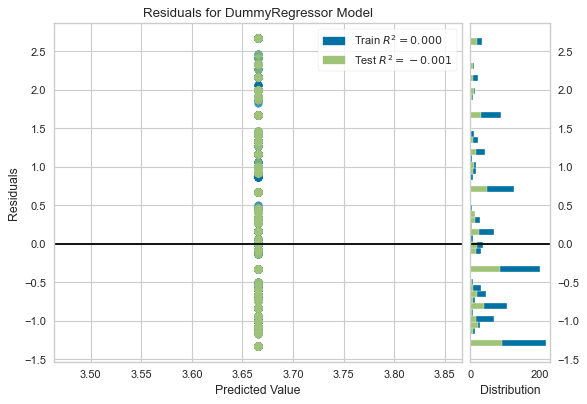

In [51]:
print("1. Residuals Plot: Muestra la varianza de los errores")
plot_model(best_model, plot='residuals', scale=0.8)

2. Prediction Error Plot: Real vs Predicho (Ideal: línea diagonal)


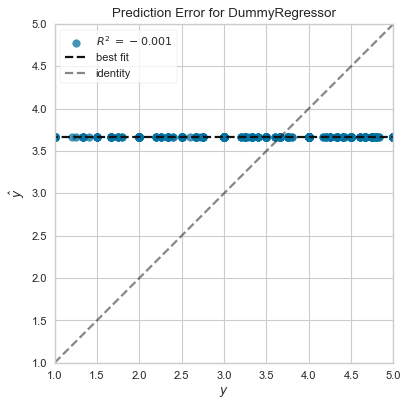

In [52]:
print("2. Prediction Error Plot: Real vs Predicho (Ideal: línea diagonal)")
plot_model(best_model, plot='error', scale=0.8)

In [53]:
try:
    print("3. Feature Importance: ¿Qué variables importan más?")
    plot_model(best_model, plot='feature', scale=0.8)
except:
    print("Este modelo no soporta feature importance plot directo.")

3. Feature Importance: ¿Qué variables importan más?
Este modelo no soporta feature importance plot directo.


4. Learning Curve: ¿Necesitamos más datos?


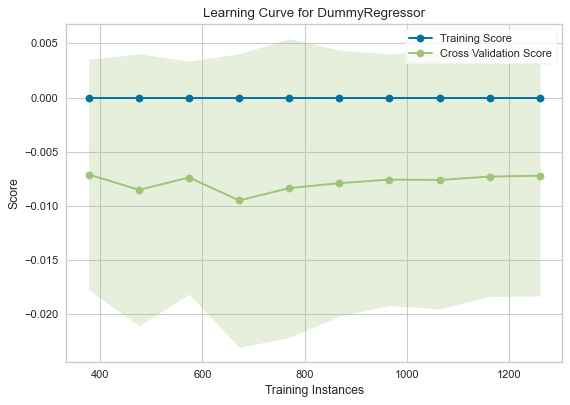

In [54]:
print("4. Learning Curve: ¿Necesitamos más datos?")
plot_model(best_model, plot='learning', scale=0.8)

## 4. Entrenamiento Final & Análisis de Errores (Scikit-learn)

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Entrenando modelo final para producción...")

# --- FIX TYPES FULL DATA START ---
# Ensure categorical features are strings
for c in cat_features:
    if c in full_data.columns:
        full_data[c] = full_data[c].astype(str)

# Ensure numeric features are floats
for c in num_features:
    if c in full_data.columns:
        full_data[c] = pd.to_numeric(full_data[c], errors='coerce')

# Ensure target is float
full_data['derived_rating'] = pd.to_numeric(full_data['derived_rating'], errors='coerce')

# Drop rows with missing target or numeric features
full_data = full_data.dropna(subset=['derived_rating'] + [c for c in num_features if c in full_data.columns])
# --- FIX TYPES FULL DATA END ---

# Add more features
cat_features_extended = cat_features + ['motivo_visita', 'acompanantes_visita']
# Ensure they are strings
for c in ['motivo_visita', 'acompanantes_visita']:
    if c in full_data.columns:
        full_data[c] = full_data[c].astype(str)

# Pipeline Sklearn
num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
                                  ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, [c for c in num_features if c in full_data.columns]),
        ('cat', cat_transformer, [c for c in cat_features_extended if c in full_data.columns])
    ])

# Use the balanced model configuration
final_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=SEED)

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', final_model)])

# Use valid_cols but ensure they exist in full_data
cols_to_use = [c for c in (cat_features_extended + num_features) if c in full_data.columns]
X = full_data[cols_to_use]
y = full_data['derived_rating']

# Train on FULL dataset for production
pipeline.fit(X, y)

# Evaluate on full dataset just to confirm it learned
y_pred = pipeline.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"\n>>> Métricas Finales (Dataset Completo):\nMAE: {mae:.4f}\nR2: {r2:.4f}")
print("Modelo listo para guardar.")

Entrenando modelo final para producción...

>>> Métricas Finales (Dataset Completo):
MAE: 0.3711
R2: 0.8021
Modelo listo para guardar.


### Análisis de Errores Finales

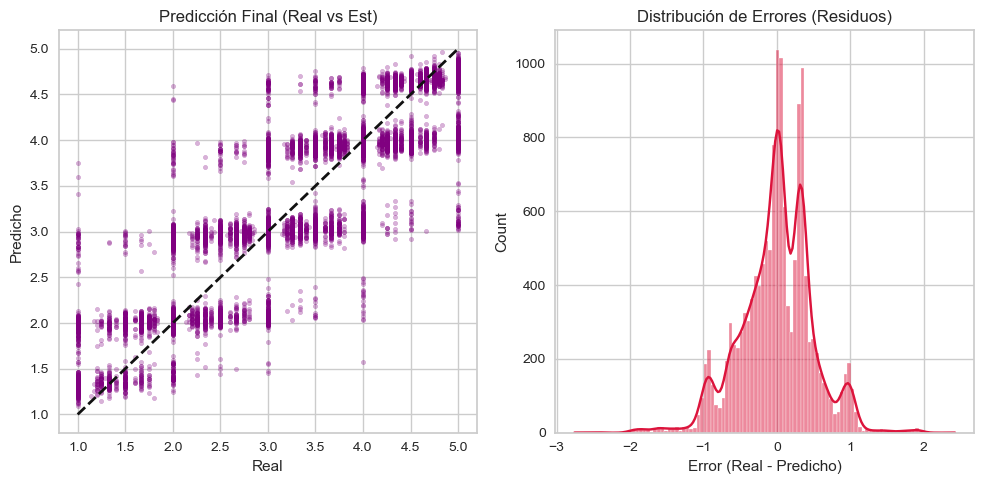

In [62]:
plt.figure(figsize=(10, 5))

# Scatter Real vs Pred
plt.subplot(1, 2, 1)
# Use y and y_pred from the full dataset training
plt.scatter(y, y_pred, alpha=0.3, color='purple', s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Predicción Final (Real vs Est)')

# Histograma de Errores
errors = y - y_pred
plt.subplot(1, 2, 2)
sns.histplot(errors, kde=True, color='crimson')
plt.title('Distribución de Errores (Residuos)')
plt.xlabel('Error (Real - Predicho)')

plt.tight_layout()
plt.show()

In [63]:
import joblib

print("¡Análisis completado! Revisa las gráficas arriba para identificar sesgos del modelo.")

# Save the model
model_path = os.path.join(MODELS_DIR, 'modelo_hibrido_v1.pkl')
joblib.dump(pipeline, model_path)
print(f"Modelo guardado en: {model_path}")

¡Análisis completado! Revisa las gráficas arriba para identificar sesgos del modelo.
Modelo guardado en: ../models\modelo_hibrido_v1.pkl
